In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [19]:
data = pd.read_csv('data.csv')
data.head(4)

,email,label
0,we know you would love to see all these wonder...,1
1,start date hourahead hour no ancillari schedul...,0
2,the deal are all in meter is on deal and meter...,0
3,per your phone messag the gri flag ha been cha...,0


In [20]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    if isinstance(text, str):

        tokens = word_tokenize(text.lower())

        tokens = [token for token in tokens if token.isalnum() and token not in stop_words]

        tokens = [lemmatizer.lemmatize(token) for token in tokens]

        return ' '.join(tokens)
    else:
        return ''

data['cleaned_text'] = data['email'].apply(clean_and_lemmatize)

data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,email,label,cleaned_text
0,we know you would love to see all these wonder...,1,know would love see wonder medic onnsal whi cc...
1,start date hourahead hour no ancillari schedul...,0,start date hourahead hour ancillari schedul aw...
2,the deal are all in meter is on deal and meter...,0,deal meter deal meter deal
3,per your phone messag the gri flag ha been cha...,0,per phone messag gri flag ha chang ye poi calp...
4,o italiano marco carola e gaetano parisio enca...,1,italiano marco carola e gaetano parisio encabe...


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.decomposition import TruncatedSVD


tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_features = tfidf_vectorizer.fit_transform(data['cleaned_text'])

print("TF-IDF Features:")
print(tfidf_features.toarray())



sentences = [text.split() for text in data['cleaned_text'].tolist()]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

def document_vector(doc):
    doc_vec = np.zeros(100)
    word_count = 0
    for word in doc:
        if word in word2vec_model.wv:
            doc_vec += word2vec_model.wv[word]
            word_count += 1
    if word_count > 0:
        doc_vec /= word_count
    return doc_vec

word2vec_features = np.array([document_vector(doc) for doc in sentences])

print("\nWord2Vec Features:")
print(word2vec_features)

TF-IDF Features:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.05094696 0.        ]
 [0.12695338 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.08454114 0.        ]]

Word2Vec Features:
[[-0.98344498  0.81578204  0.23231299 ...  0.44824268 -0.31312672
   0.27152322]
 [-1.76128996  1.48113294  0.28521962 ...  0.73010063  0.92013912
   0.22302492]
 [-3.91545286  2.1135561   0.41572359 ...  1.11374271 -1.3186048
  -1.69125748]
 ...
 [-1.8119418   2.01710986 -0.12806716 ...  1.05100892 -0.1231726
   0.41115482]
 [-1.72449354  1.67315209 -0.32487239 ...  1.23151505 -0.11659291
   0.29631908]
 [-1.34040007  1.19028156  1.15293867 ...  0.74698932 -0.45126991
   0.30499902]]


In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



X = word2vec_features
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lstm = Sequential()
model_lstm.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_lstm.fit(np.expand_dims(X_train, axis=2), y_train, epochs=10, batch_size=32, validation_split=0.1)

loss, accuracy = model_lstm.evaluate(np.expand_dims(X_test, axis=2), y_test)
print("LSTM Accuracy:", accuracy)

Epoch 1/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 72s 93ms/step - accuracy: 0.8222 - loss: 0.3915 - val_accuracy: 0.9441 - val_loss: 0.1593
Epoch 2/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.9414 - loss: 0.1568 - val_accuracy: 0.9569 - val_loss: 0.1255
Epoch 3/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.9529 - loss: 0.1386 - val_accuracy: 0.9617 - val_loss: 0.1129
Epoch 4/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.9572 - loss: 0.1239 - val_accuracy: 0.9365 - val_loss: 0.1525
Epoch 5/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9643 - loss: 0.1032 - val_accuracy: 0.9641 - val_loss: 0.1027
Epoch 6/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.9661 - loss: 0.0994 - val_accuracy: 0.9673 - val_loss: 0.0902
Epoch 7/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.9694 - loss: 0.0920 - val_accuracy: 0.9673 - val_loss: 0.0933
Epoch 8/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.9692 - loss: 0.0869 - 

In [26]:
model_xlstm = Sequential()
model_xlstm.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train.shape[1], 1)))
model_xlstm.add(Bidirectional(LSTM(64)))
model_xlstm.add(Dense(1, activation='sigmoid'))

model_xlstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_xlstm.fit(np.expand_dims(X_train, axis=2), y_train, epochs=10, batch_size=32, validation_split=0.1)

loss, accuracy = model_xlstm.evaluate(np.expand_dims(X_test, axis=2), y_test)
print("XLSTM Accuracy:", accuracy)

Epoch 1/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 174s 225ms/step - accuracy: 0.8605 - loss: 0.3164 - val_accuracy: 0.9585 - val_loss: 0.1140
Epoch 2/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 156s 221ms/step - accuracy: 0.9571 - loss: 0.1226 - val_accuracy: 0.9641 - val_loss: 0.0973
Epoch 3/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 152s 215ms/step - accuracy: 0.9645 - loss: 0.1037 - val_accuracy: 0.9541 - val_loss: 0.1094
Epoch 4/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 152s 215ms/step - accuracy: 0.9665 - loss: 0.0931 - val_accuracy: 0.9713 - val_loss: 0.0777
Epoch 5/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.9710 - loss: 0.0834 - val_accuracy: 0.9701 - val_loss: 0.0835
Epoch 6/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.9681 - loss: 0.0934 - val_accuracy: 0.9749 - val_loss: 0.0700
Epoch 7/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.9753 - loss: 0.0733 - val_accuracy: 0.9693 - val_loss: 0.0831
Epoch 8/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 154s 218ms/step - accuracy: 0.9728 -

196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step
LSTM Metrics:
  F1 Score: 0.9741310903031265
  Accuracy: 0.9739699776429256
  Precision: 0.9650943396226415
XLSTM Metrics:
  F1 Score: 0.97472
  Accuracy: 0.9747684445863941
  Precision: 0.9734739533397252


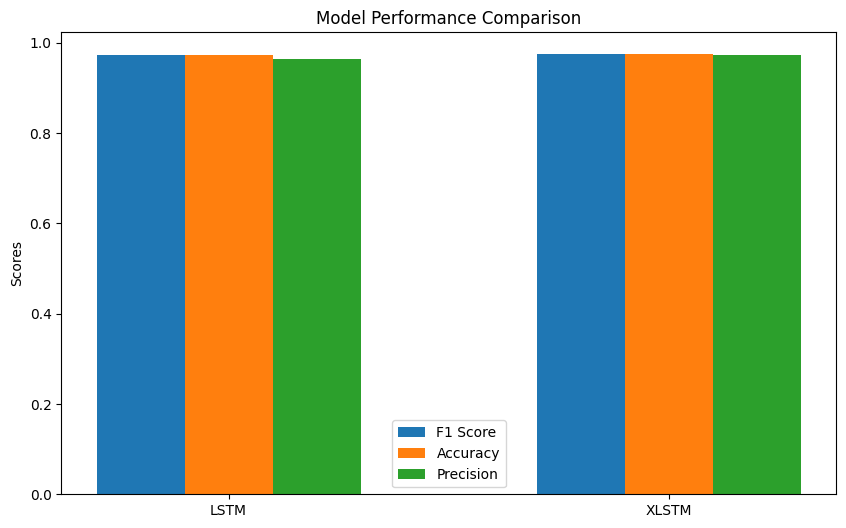

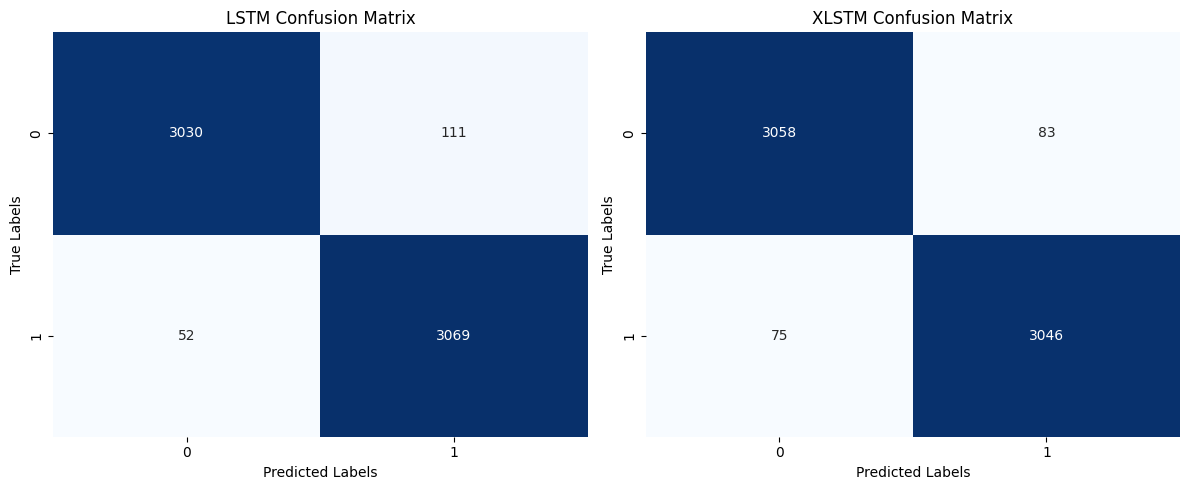

In [27]:
from sklearn.metrics import f1_score, accuracy_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_lstm = (model_lstm.predict(np.expand_dims(X_test, axis=2)) > 0.5).astype("int32")
y_pred_xlstm = (model_xlstm.predict(np.expand_dims(X_test, axis=2)) > 0.5).astype("int32")


def evaluate_model(y_true, y_pred, model_name):
  f1 = f1_score(y_true, y_pred)
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  print(f"{model_name} Metrics:")
  print(f"  F1 Score: {f1}")
  print(f"  Accuracy: {accuracy}")
  print(f"  Precision: {precision}")
  return f1, accuracy, precision


f1_lstm, accuracy_lstm, precision_lstm = evaluate_model(y_test, y_pred_lstm, "LSTM")
f1_xlstm, accuracy_xlstm, precision_xlstm = evaluate_model(y_test, y_pred_xlstm, "XLSTM")

models = ["LSTM", "XLSTM"]
f1_scores = [f1_lstm, f1_xlstm]
accuracy_scores = [accuracy_lstm, accuracy_xlstm]
precision_scores = [precision_lstm, precision_xlstm]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1 Score')
rects2 = ax.bar(x, accuracy_scores, width, label='Accuracy')
rects3 = ax.bar(x + width, precision_scores, width, label='Precision')


ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(12, 5))
cm_xlstm = confusion_matrix(y_test, y_pred_xlstm)

plt.subplot(1, 2, 1)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')


plt.subplot(1, 2, 2)
sns.heatmap(cm_xlstm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('XLSTM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [39]:
import random
from deap import base, creator, tools, algorithms
from sklearn.model_selection import cross_val_score

# Define problem type: we're maximizing accuracy
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Define the hyperparameter space
param_grid = {
    'lstm_units': [32, 64, 128, 256],
    'batch_size': [16, 32, 64],
    'epochs': [5, 10, 15],
    'learning_rate': [0.001, 0.01, 0.1]
}

# Generate random individuals (hyperparameter sets)
def generate_individual():
    return [
        random.choice(param_grid['lstm_units']),
        random.choice(param_grid['batch_size']),
        random.choice(param_grid['epochs']),
        random.choice(param_grid['learning_rate']),
    ]

# Define the fitness function
def evaluate_individual(individual):
    lstm_units, batch_size, epochs, learning_rate = individual

    # Build model with given hyperparameters
    model_lstm = Sequential()
    model_lstm.add(LSTM(lstm_units, input_shape=(X_train.shape[1], 1)))
    model_lstm.add(Dense(1, activation='sigmoid'))

    model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train the model and evaluate
    model_lstm.fit(np.expand_dims(X_train, axis=2), y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    loss, accuracy = model_lstm.evaluate(np.expand_dims(X_test, axis=2), y_test, verbose=0)

    return accuracy,  # Tuple, GA expects an iterable for returning fitness values

# Create the toolbox for the Genetic Algorithm
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxTwoPoint)  # Crossover
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)  # Mutation
toolbox.register("select", tools.selTournament, tournsize=3)  # Selection
toolbox.register("evaluate", evaluate_individual)

# Create the population
population = toolbox.population(n=10)  # 10 individuals in the population

# Run the Genetic Algorithm
def run_ga():
    # Set the number of generations and number of iterations per generation
    generations = 3
    for gen in range(generations):
        print(f"Generation {gen + 1}")
        
        # Evaluate the fitness of all individuals
        fits = list(map(toolbox.evaluate, population))

        # Update the fitness of individuals
        for ind, fit in zip(population, fits):
            ind.fitness.values = fit

        # Select the best individuals
        best_individuals = toolbox.select(population, len(population) // 2)

        # Clone the selected individuals
        offspring = list(map(toolbox.clone, best_individuals))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < 0.7:  # Crossover probability
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < 0.2:  # Mutation probability
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the new offspring
        invalid_individuals = [ind for ind in offspring if not ind.fitness.valid]
        fits = list(map(toolbox.evaluate, invalid_individuals))

        # Update the fitness values
        for ind, fit in zip(invalid_individuals, fits):
            ind.fitness.values = fit

        # Replace the old population with the new one
        population[:] = offspring

    # Return the best individual
    best_individual = tools.selBest(population, 1)[0]
    print(f"Best Individual: {best_individual}")
    return best_individual

best_individual = run_ga()

# Best hyperparameters after the Genetic Algorithm
lstm_units, batch_size, epochs, learning_rate = best_individual
print(f"Best hyperparameters - LSTM Units: {lstm_units}, Batch Size: {batch_size}, Epochs: {epochs}, Learning Rate: {learning_rate}")


Generation 1
Generation 2
Generation 3
Best Individual: [256, 32, 10, -0.6496340725213903]
Best hyperparameters - LSTM Units: 256, Batch Size: 32, Epochs: 10, Learning Rate: -0.6496340725213903


In [40]:

# Extract the best hyperparameters after the GA run
lstm_units, batch_size, epochs, learning_rate = best_individual

# Build and compile the final model using the best hyperparameters
model_lstm = Sequential()
model_lstm.add(LSTM(lstm_units, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model with the best hyperparameters
model_lstm.fit(np.expand_dims(X_train, axis=2), y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

# Evaluate the model on the test set
loss, accuracy = model_lstm.evaluate(np.expand_dims(X_test, axis=2), y_test)

print(f"Final Model Accuracy: {accuracy * 100:.2f}%")


196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9714 - loss: 0.0795
Final Model Accuracy: 97.40%


In [2]:
from deap import base, creator, tools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
import random

# Define problem type: we're maximizing accuracy
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Define the hyperparameter space
param_grid = {
    'lstm_units': [32, 64, 128, 256],
    'batch_size': [16, 32, 64],
    'epochs': [5, 10, 15],
    'learning_rate': [0.001, 0.01, 0.1]
}

# Generate random individuals (hyperparameter sets)
def generate_individual():
    return [
        random.choice(param_grid['lstm_units']),
        random.choice(param_grid['batch_size']),
        random.choice(param_grid['epochs']),
        random.choice(param_grid['learning_rate']),
    ]

# Define the fitness function
def evaluate_individual(individual):
    lstm_units, batch_size, epochs, learning_rate = individual

    # Build XLSTM model with given hyperparameters
    model_xlstm = Sequential()
    model_xlstm.add(Bidirectional(LSTM(lstm_units, return_sequences=True), input_shape=(X_train.shape[1], 1)))
    model_xlstm.add(Bidirectional(LSTM(lstm_units // 2)))
    model_xlstm.add(Dense(1, activation='sigmoid'))

    model_xlstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train the model and evaluate
    model_xlstm.fit(np.expand_dims(X_train, axis=2), y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    loss, accuracy = model_xlstm.evaluate(np.expand_dims(X_test, axis=2), y_test, verbose=0)

    return accuracy,  # Tuple, GA expects an iterable for returning fitness values

# Create the toolbox for the Genetic Algorithm
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxTwoPoint)  # Crossover
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)  # Mutation
toolbox.register("select", tools.selTournament, tournsize=3)  # Selection
toolbox.register("evaluate", evaluate_individual)

# Create the population
population = toolbox.population(n=10)  # 10 individuals in the population

# Run the Genetic Algorithm
def run_ga():
    # Set the number of generations and number of iterations per generation
    generations = 3
    for gen in range(generations):
        print(f"Generation {gen + 1}")
        
        # Evaluate the fitness of all individuals
        fits = list(map(toolbox.evaluate, population))

        # Update the fitness of individuals
        for ind, fit in zip(population, fits):
            ind.fitness.values = fit

        # Select the best individuals
        best_individuals = toolbox.select(population, len(population) // 2)

        # Clone the selected individuals
        offspring = list(map(toolbox.clone, best_individuals))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < 0.7:  # Crossover probability
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < 0.2:  # Mutation probability
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the new offspring
        invalid_individuals = [ind for ind in offspring if not ind.fitness.valid]
        fits = list(map(toolbox.evaluate, invalid_individuals))

        # Update the fitness values
        for ind, fit in zip(invalid_individuals, fits):
            ind.fitness.values = fit

        # Replace the old population with the new one
        population[:] = offspring

    # Return the best individual
    best_individual = tools.selBest(population, 1)[0]
    print(f"Best Individual: {best_individual}")
    return best_individual

# Call the GA and get the best individual
best_individual = run_ga()

# Best hyperparameters after the Genetic Algorithm
lstm_units, batch_size, epochs, learning_rate = best_individual
print(f"Best hyperparameters - LSTM Units: {lstm_units}, Batch Size: {batch_size}, Epochs: {epochs}, Learning Rate: {learning_rate}")

# Evaluate final XLSTM model with best hyperparameters
final_model = Sequential()
final_model.add(Bidirectional(LSTM(lstm_units, return_sequences=True), input_shape=(X_train.shape[1], 1)))
final_model.add(Bidirectional(LSTM(lstm_units // 2)))
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the final XLSTM model
final_model.fit(np.expand_dims(X_train, axis=2), y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

# Evaluate on the test set
loss, accuracy = final_model.evaluate(np.expand_dims(X_test, axis=2), y_test, verbose=0)

print(f"Final XLSTM Model Accuracy: {accuracy * 100:.2f}%")


Generation 1


NameError: name 'X_train' is not defined